# Toy workflow: Flood-fragility-informed Noisy-OR Bayesian Network / DBN for hospital–critical infrastructure

This notebook shows a **toy but complete workflow** for a hospital–critical infrastructure (HCI) study under hurricane flooding.

The example includes:

- one hospital,
- one power plant,
- one substation,
- one water treatment plant,
- three communication towers.

The workflow demonstrates how to:

1. define raw data inputs from real-world logs and expert knowledge;
2. convert flood depth into infrastructure failure probability using fragility curves;
3. propagate infrastructure failures through a Bayesian Network;
4. use Noisy-OR / cumulative Noisy-OR to reduce CPT burden;
5. update posterior probabilities when observations arrive;
6. represent the raw data structure for a Dynamic Bayesian Network (DBN);
7. run a simple time-sliced DBN-style filtering example.

> This notebook intentionally avoids specialized Bayesian Network packages so that the logic is transparent. For larger networks, you may later move the same structure into GeNIe/SMILE, pgmpy, pomegranate, or another BN/DBN library.

## 0. Imports and helper functions

We use only common Python packages.

The helper functions below include:

- a standard normal CDF;
- a lognormal fragility curve;
- binary probability utilities;
- a Noisy-OR function;
- an ordinal/cumulative Noisy-OR function for hospital functionality.

In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


def normal_cdf(x):
    """Standard normal CDF using the error function."""
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def lognormal_fragility(depth_m, median_depth_m, beta):
    """
    Lognormal fragility curve.

    Parameters
    ----------
    depth_m : float
        Local flood depth at the asset, in meters.
    median_depth_m : float
        Flood depth where failure probability is 0.5.
    beta : float
        Lognormal dispersion parameter.

    Returns
    -------
    float
        P(failure | flood depth).
    """
    if depth_m <= 0:
        return 0.0

    z = (math.log(depth_m) - math.log(median_depth_m)) / beta
    return normal_cdf(z)


def bernoulli_prob(value, p_true):
    """Probability of a binary value given P(True)."""
    return p_true if value == 1 else (1.0 - p_true)


def noisy_or_failure(parent_failures, strengths, leak=0.0):
    """
    Noisy-OR for a binary child failure event.

    parent_failures[i] = 1 means cause i is present.
    strengths[i] is the probability that cause i independently triggers the child failure.
    leak is the probability of child failure when no listed cause is present.

    Returns P(child_failure = 1 | parent_failures).
    """
    survival = 1.0 - leak
    for x, s in zip(parent_failures, strengths):
        if x == 1:
            survival *= (1.0 - s)
    return 1.0 - survival


def cumulative_noisy_or_hospital(parent_failures, threshold_strengths, leak):
    """
    Cumulative Noisy-OR for an ordinal hospital outcome.

    This estimates P(Hospital state >= threshold | parent failures).

    Example thresholds:
    - >= Reduced
    - >= Critical
    - >= Failed
    """
    return noisy_or_failure(parent_failures, threshold_strengths, leak)


def hospital_state_distribution(parent_failures, hospital_params):
    """
    Converts cumulative threshold probabilities into a distribution over:

    Normal, Reduced, Critical, Failed.

    P(Normal)   = 1 - P(H >= Reduced)
    P(Reduced)  = P(H >= Reduced) - P(H >= Critical)
    P(Critical) = P(H >= Critical) - P(H >= Failed)
    P(Failed)   = P(H >= Failed)

    The threshold parameters should be selected so that:
    P(H >= Reduced) >= P(H >= Critical) >= P(H >= Failed)
    for all parent combinations.
    """
    p_ge_reduced = cumulative_noisy_or_hospital(
        parent_failures,
        hospital_params["ge_reduced"]["strengths"],
        hospital_params["ge_reduced"]["leak"],
    )

    p_ge_critical = cumulative_noisy_or_hospital(
        parent_failures,
        hospital_params["ge_critical"]["strengths"],
        hospital_params["ge_critical"]["leak"],
    )

    p_ge_failed = cumulative_noisy_or_hospital(
        parent_failures,
        hospital_params["ge_failed"]["strengths"],
        hospital_params["ge_failed"]["leak"],
    )

    # Numerical guardrails for toy examples.
    p_ge_critical = min(p_ge_critical, p_ge_reduced)
    p_ge_failed = min(p_ge_failed, p_ge_critical)

    return {
        "Normal": 1.0 - p_ge_reduced,
        "Reduced": p_ge_reduced - p_ge_critical,
        "Critical": p_ge_critical - p_ge_failed,
        "Failed": p_ge_failed,
    }


def normalize(dictionary):
    total = sum(dictionary.values())
    if total == 0:
        return {k: np.nan for k in dictionary}
    return {k: v / total for k, v in dictionary.items()}

## 1. Raw data inputs: what would come from real-world logs versus expert knowledge?

In a real study, the input data usually come from several sources:

| Input type | Example source | Role in the model |
|---|---|---|
| Asset inventory | GIS layers, utility asset data, FCC/ASR tower data, HIFLD, local government files | Defines nodes and locations |
| Flood depth | Hydrodynamic model, FEMA flood products, storm-surge model, high-water marks, sensors | Drives fragility-based physical failure probabilities |
| Infrastructure outage logs | Utility outage logs, emergency operations center reports, hospital facility reports, SCADA records | Provides observations for posterior updating |
| Hospital operational status | Hospital emergency management logs, status reports, bed/ED diversion data | Provides evidence for hospital state |
| Expert knowledge | Structured interviews, Delphi survey, engineering judgment | Provides causal strengths and leak probabilities when observations are limited |

Below are toy input tables with the same structure you might use for real data.

In [2]:
# -------------------------
# 1.1 Asset inventory
# -------------------------
# Real-world replacement:
# - GIS point/line layers of power plants, substations, water treatment plants, communication towers, and hospitals.
# - Attributes should include asset type, operator/provider, location, elevation, and service relationship to hospitals.

asset_inventory = pd.DataFrame([
    {"node_id": "HOSP_1", "node_type": "Hospital", "name": "Toy County Hospital", "operator": "Toy Health", "lat": 26.60, "lon": -81.87, "elevation_m": 3.0},
    {"node_id": "PP_1", "node_type": "PowerPlant", "name": "Toy Power Plant", "operator": "Utility A", "lat": 26.65, "lon": -81.80, "elevation_m": 2.5},
    {"node_id": "SUB_1", "node_type": "Substation", "name": "Toy Substation", "operator": "Utility A", "lat": 26.62, "lon": -81.84, "elevation_m": 2.0},
    {"node_id": "WTP_1", "node_type": "WaterTreatmentPlant", "name": "Toy Water Treatment Plant", "operator": "Water Utility B", "lat": 26.58, "lon": -81.90, "elevation_m": 2.2},
    {"node_id": "TOWER_A", "node_type": "CommunicationTower", "name": "Tower A", "operator": "Carrier X", "lat": 26.61, "lon": -81.86, "elevation_m": 3.5},
    {"node_id": "TOWER_B", "node_type": "CommunicationTower", "name": "Tower B", "operator": "Carrier Y", "lat": 26.64, "lon": -81.88, "elevation_m": 2.1},
    {"node_id": "TOWER_C", "node_type": "CommunicationTower", "name": "Tower C", "operator": "Carrier Z", "lat": 26.57, "lon": -81.82, "elevation_m": 1.7},
])

asset_inventory

,node_id,node_type,name,operator,lat,lon,elevation_m
0,HOSP_1,Hospital,Toy County Hospital,Toy Health,26.60,-81.87,3.0
1,PP_1,PowerPlant,Toy Power Plant,Utility A,26.65,-81.80,2.5
2,SUB_1,Substation,Toy Substation,Utility A,26.62,-81.84,2.0
3,WTP_1,WaterTreatmentPlant,Toy Water Treatment Plant,Water Utility B,26.58,-81.90,2.2
4,TOWER_A,CommunicationTower,Tower A,Carrier X,26.61,-81.86,3.5
5,TOWER_B,CommunicationTower,Tower B,Carrier Y,26.64,-81.88,2.1
6,TOWER_C,CommunicationTower,Tower C,Carrier Z,26.57,-81.82,1.7


In [3]:
# -------------------------
# 1.2 Dependency structure
# -------------------------
# This can come from infrastructure maps, engineering assumptions, utility service areas,
# interviews, or nearest-provider assumptions when direct service records are unavailable.

dependency_edges = pd.DataFrame([
    {"parent": "PP_1", "child": "SUB_1", "relationship": "Power plant supports substation"},
    {"parent": "SUB_1", "child": "HOSP_1", "relationship": "Substation supplies hospital electricity"},
    {"parent": "WTP_1", "child": "HOSP_1", "relationship": "Water treatment plant supports hospital water supply"},
    {"parent": "TOWER_A", "child": "HOSP_1", "relationship": "Tower supports hospital communication"},
    {"parent": "TOWER_B", "child": "HOSP_1", "relationship": "Tower supports hospital communication"},
    {"parent": "TOWER_C", "child": "HOSP_1", "relationship": "Tower supports hospital communication"},
])

dependency_edges

,parent,child,relationship
0,PP_1,SUB_1,Power plant supports substation
1,SUB_1,HOSP_1,Substation supplies hospital electricity
2,WTP_1,HOSP_1,Water treatment plant supports hospital water ...
3,TOWER_A,HOSP_1,Tower supports hospital communication
4,TOWER_B,HOSP_1,Tower supports hospital communication
5,TOWER_C,HOSP_1,Tower supports hospital communication


In [4]:
# -------------------------
# 1.3 Flood-depth input for one hurricane scenario at one time step
# -------------------------
# Real-world replacement:
# - Hydrodynamic model output intersected with asset locations.
# - Sensor/gauge/high-water-mark measurements assigned to assets.
# - Remote sensing / field survey estimates.

flood_depth_t0 = pd.DataFrame([
    {"scenario_id": "ToyHurricane", "time_step": 0, "node_id": "PP_1", "flood_depth_m": 0.60, "source": "hydrodynamic_model"},
    {"scenario_id": "ToyHurricane", "time_step": 0, "node_id": "SUB_1", "flood_depth_m": 1.40, "source": "hydrodynamic_model"},
    {"scenario_id": "ToyHurricane", "time_step": 0, "node_id": "WTP_1", "flood_depth_m": 1.10, "source": "hydrodynamic_model"},
    {"scenario_id": "ToyHurricane", "time_step": 0, "node_id": "TOWER_A", "flood_depth_m": 0.30, "source": "hydrodynamic_model"},
    {"scenario_id": "ToyHurricane", "time_step": 0, "node_id": "TOWER_B", "flood_depth_m": 1.20, "source": "hydrodynamic_model"},
    {"scenario_id": "ToyHurricane", "time_step": 0, "node_id": "TOWER_C", "flood_depth_m": 2.00, "source": "hydrodynamic_model"},
])

flood_depth_t0

,scenario_id,time_step,node_id,flood_depth_m,source
0,ToyHurricane,0,PP_1,0.6,hydrodynamic_model
1,ToyHurricane,0,SUB_1,1.4,hydrodynamic_model
2,ToyHurricane,0,WTP_1,1.1,hydrodynamic_model
3,ToyHurricane,0,TOWER_A,0.3,hydrodynamic_model
4,ToyHurricane,0,TOWER_B,1.2,hydrodynamic_model
5,ToyHurricane,0,TOWER_C,2.0,hydrodynamic_model


In [5]:
# -------------------------
# 1.4 Outage/observation logs
# -------------------------
# Real-world replacement:
# - Utility outage feeds
# - Emergency operations center situation reports
# - Hospital facility logs
# - SCADA alarms
# - Field inspection reports
#
# observed_failed:
# - 1 means observed failed/down/unavailable
# - 0 means observed operational/available
# - NaN means no observation

infrastructure_observation_logs = pd.DataFrame([
    {"time_step": 0, "node_or_service": "TOWER_B", "observed_failed": 1, "source": "EOC situation report", "confidence": 0.90, "notes": "Carrier Y tower reported down"},
    {"time_step": 0, "node_or_service": "SUB_1", "observed_failed": np.nan, "source": "unknown", "confidence": np.nan, "notes": "No direct report yet"},
    {"time_step": 0, "node_or_service": "WaterSupply", "observed_failed": np.nan, "source": "unknown", "confidence": np.nan, "notes": "No direct report yet"},
])

hospital_status_logs = pd.DataFrame([
    {"time_step": 0, "hospital_id": "HOSP_1", "observed_state": "Critical", "source": "hospital emergency manager", "confidence": 0.85, "notes": "Hospital reports critical operations"},
])

display(infrastructure_observation_logs)
display(hospital_status_logs)

,time_step,node_or_service,observed_failed,source,confidence,notes
0,0,TOWER_B,1.0,EOC situation report,0.9,Carrier Y tower reported down
1,0,SUB_1,NaN,unknown,NaN,No direct report yet
2,0,WaterSupply,NaN,unknown,NaN,No direct report yet


,time_step,hospital_id,observed_state,source,confidence,notes
0,0,HOSP_1,Critical,hospital emergency manager,0.85,Hospital reports critical operations


In [6]:
# -------------------------
# 1.5 Expert-elicited parameters
# -------------------------
# Real-world replacement:
# - Structured interviews with utility engineers, hospital facility managers, emergency managers.
# - Use verbal anchors such as very low / low / medium / high, then map to numerical ranges.
# - Aggregate experts using arithmetic mean, geometric mean, Cooke's method, Delphi consensus, etc.
#
# Here, causal_strength means:
# "If this parent fails, how likely is it to independently trigger failure/degradation of the child?"

expert_causal_strengths = pd.DataFrame([
    {"parent": "PP_1_failed", "child": "SUB_1_failed", "causal_strength": 0.65, "source": "expert_elicitation", "rationale": "Substation depends on upstream generation/transmission availability"},
    {"parent": "SUB_1_physical_failed", "child": "SUB_1_failed", "causal_strength": 0.90, "source": "expert_elicitation", "rationale": "Physical substation flooding usually causes operational failure"},

    {"parent": "WTP_1_physical_failed", "child": "WaterSupply_failed", "causal_strength": 0.90, "source": "expert_elicitation", "rationale": "Water treatment plant failure strongly affects potable water availability"},
    {"parent": "SUB_1_failed", "child": "WaterSupply_failed", "causal_strength": 0.25, "source": "expert_elicitation", "rationale": "Water supply may be affected by power loss but backup systems may exist"},

    {"parent": "TOWER_A_failed", "child": "Communication_failed", "causal_strength": 0.40, "source": "expert_elicitation", "rationale": "Tower A is the nearest tower"},
    {"parent": "TOWER_B_failed", "child": "Communication_failed", "causal_strength": 0.35, "source": "expert_elicitation", "rationale": "Tower B provides partial redundancy"},
    {"parent": "TOWER_C_failed", "child": "Communication_failed", "causal_strength": 0.30, "source": "expert_elicitation", "rationale": "Tower C provides partial redundancy"},
    {"parent": "SUB_1_failed", "child": "Communication_failed", "causal_strength": 0.25, "source": "expert_elicitation", "rationale": "Local power outage can affect tower operation if backup power is insufficient"},
])

expert_causal_strengths

,parent,child,causal_strength,source,rationale
0,PP_1_failed,SUB_1_failed,0.65,expert_elicitation,Substation depends on upstream generation/tran...
1,SUB_1_physical_failed,SUB_1_failed,0.90,expert_elicitation,Physical substation flooding usually causes op...
2,WTP_1_physical_failed,WaterSupply_failed,0.90,expert_elicitation,Water treatment plant failure strongly affects...
3,SUB_1_failed,WaterSupply_failed,0.25,expert_elicitation,Water supply may be affected by power loss but...
4,TOWER_A_failed,Communication_failed,0.40,expert_elicitation,Tower A is the nearest tower
5,TOWER_B_failed,Communication_failed,0.35,expert_elicitation,Tower B provides partial redundancy
6,TOWER_C_failed,Communication_failed,0.30,expert_elicitation,Tower C provides partial redundancy
7,SUB_1_failed,Communication_failed,0.25,expert_elicitation,Local power outage can affect tower operation ...


## 2. Fragility curves: from flood depth to physical failure probability

For each asset type, define a fragility curve:

$$
P(F_i = 1 \mid d_i) =
\Phi\left(
\frac{\ln(d_i)-\ln(m_i)}{\beta_i}
\right)
$$

where:

- \(F_i=1\) means asset \(i\) physically fails;
- \(d_i\) is flood depth at asset \(i\);
- \(m_i\) is median failure depth;
- \(\beta_i\) is lognormal dispersion;
- \(\Phi(\cdot)\) is the standard normal CDF.

In a real study, fragility parameters may come from:

- engineering literature,
- empirical post-disaster damage data,
- component-level vulnerability models,
- expert elicitation when literature is unavailable.

In [7]:
# Toy fragility parameters by asset type.
# These are illustrative only, not validated engineering values.

fragility_parameters = pd.DataFrame([
    {"node_type": "PowerPlant", "median_depth_m": 2.00, "beta": 0.45, "failure_mode": "flood-induced physical/operational failure"},
    {"node_type": "Substation", "median_depth_m": 1.00, "beta": 0.40, "failure_mode": "flood-induced electrical equipment failure"},
    {"node_type": "WaterTreatmentPlant", "median_depth_m": 1.20, "beta": 0.45, "failure_mode": "flood-induced treatment plant failure"},
    {"node_type": "CommunicationTower", "median_depth_m": 1.40, "beta": 0.50, "failure_mode": "flood-induced tower/support equipment failure"},
])

fragility_parameters

,node_type,median_depth_m,beta,failure_mode
0,PowerPlant,2.0,0.45,flood-induced physical/operational failure
1,Substation,1.0,0.40,flood-induced electrical equipment failure
2,WaterTreatmentPlant,1.2,0.45,flood-induced treatment plant failure
3,CommunicationTower,1.4,0.50,flood-induced tower/support equipment failure


In [8]:
# Join asset inventory, flood depth, and fragility parameters.
node_fragility_input = (
    flood_depth_t0
    .merge(asset_inventory[["node_id", "node_type", "name"]], on="node_id", how="left")
    .merge(fragility_parameters, on="node_type", how="left")
)

node_fragility_input["p_physical_failure"] = node_fragility_input.apply(
    lambda row: lognormal_fragility(
        row["flood_depth_m"],
        row["median_depth_m"],
        row["beta"]
    ),
    axis=1
)

node_fragility_input[[
    "node_id", "name", "node_type", "flood_depth_m",
    "median_depth_m", "beta", "p_physical_failure"
]]

,node_id,name,node_type,flood_depth_m,median_depth_m,beta,p_physical_failure
0,PP_1,Toy Power Plant,PowerPlant,0.6,2.0,0.45,0.003731
1,SUB_1,Toy Substation,Substation,1.4,1.0,0.40,0.799877
2,WTP_1,Toy Water Treatment Plant,WaterTreatmentPlant,1.1,1.2,0.45,0.423339
3,TOWER_A,Tower A,CommunicationTower,0.3,1.4,0.50,0.001032
4,TOWER_B,Tower B,CommunicationTower,1.2,1.4,0.50,0.378927
5,TOWER_C,Tower C,CommunicationTower,2.0,1.4,0.50,0.762185


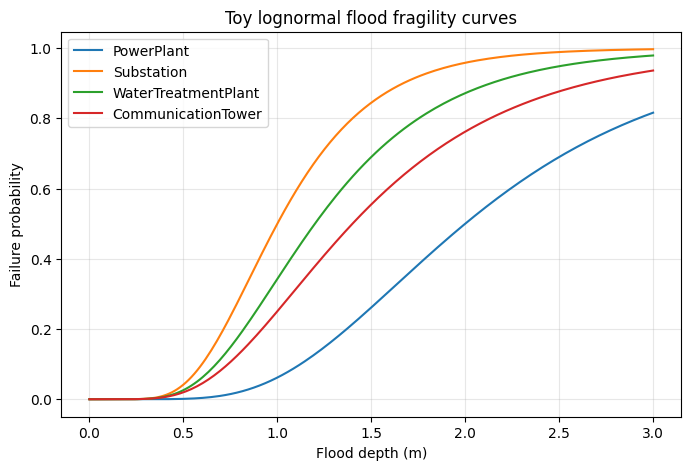

In [9]:
# Plot the toy fragility curves.
depth_grid = np.linspace(0, 3.0, 200)

plt.figure(figsize=(8, 5))
for _, row in fragility_parameters.iterrows():
    probs = [
        lognormal_fragility(d, row["median_depth_m"], row["beta"])
        for d in depth_grid
    ]
    plt.plot(depth_grid, probs, label=row["node_type"])

plt.xlabel("Flood depth (m)")
plt.ylabel("Failure probability")
plt.title("Toy lognormal flood fragility curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Bayesian Network structure

The toy BN uses the following structure.

### Physical failure from flood depth

```text
Flood depth at asset → Physical failure probability
```

### Infrastructure operational failure

```text
PowerPlant physical failure → PowerPlant failed

Substation physical failure → Substation failed
PowerPlant failed             → Substation failed

WTP physical failure → Water supply failed
Substation failed    → Water supply failed

Tower A failed       → Communication failed
Tower B failed       → Communication failed
Tower C failed       → Communication failed
Substation failed    → Communication failed
```

### Hospital functionality

```text
Substation failed
Water supply failed       → Hospital functionality
Communication failed
```

The hospital state is ordinal:

```text
Normal < Reduced < Critical < Failed
```

We use cumulative Noisy-OR thresholds:

- \(P(H \geq \text{Reduced})\)
- \(P(H \geq \text{Critical})\)
- \(P(H \geq \text{Failed})\)

Then we convert the threshold probabilities into probabilities for exactly Normal, Reduced, Critical, and Failed.

In [10]:
# Root physical failure priors from fragility curves.
# All values are P(failure = 1).

root_priors = {
    "PP_1_failed": float(node_fragility_input.loc[node_fragility_input["node_id"] == "PP_1", "p_physical_failure"].iloc[0]),
    "SUB_1_physical_failed": float(node_fragility_input.loc[node_fragility_input["node_id"] == "SUB_1", "p_physical_failure"].iloc[0]),
    "WTP_1_physical_failed": float(node_fragility_input.loc[node_fragility_input["node_id"] == "WTP_1", "p_physical_failure"].iloc[0]),
    "TOWER_A_failed": float(node_fragility_input.loc[node_fragility_input["node_id"] == "TOWER_A", "p_physical_failure"].iloc[0]),
    "TOWER_B_failed": float(node_fragility_input.loc[node_fragility_input["node_id"] == "TOWER_B", "p_physical_failure"].iloc[0]),
    "TOWER_C_failed": float(node_fragility_input.loc[node_fragility_input["node_id"] == "TOWER_C", "p_physical_failure"].iloc[0]),
}

pd.DataFrame(
    [{"variable": k, "prior_p_failure_from_fragility": v} for k, v in root_priors.items()]
)

,variable,prior_p_failure_from_fragility
0,PP_1_failed,0.003731
1,SUB_1_physical_failed,0.799877
2,WTP_1_physical_failed,0.423339
3,TOWER_A_failed,0.001032
4,TOWER_B_failed,0.378927
5,TOWER_C_failed,0.762185


In [11]:
# Conditional Noisy-OR parameters.
# These come from expert knowledge in the toy example.

conditional_params = {
    "SUB_1_failed": {
        "parents": ["SUB_1_physical_failed", "PP_1_failed"],
        "strengths": [0.90, 0.65],
        "leak": 0.02,
    },
    "WaterSupply_failed": {
        "parents": ["WTP_1_physical_failed", "SUB_1_failed"],
        "strengths": [0.90, 0.25],
        "leak": 0.03,
    },
    "Communication_failed": {
        "parents": ["TOWER_A_failed", "TOWER_B_failed", "TOWER_C_failed", "SUB_1_failed"],
        "strengths": [0.40, 0.35, 0.30, 0.25],
        "leak": 0.02,
    }
}

# Hospital functionality parameters.
# Parent order: [SUB_1_failed, WaterSupply_failed, Communication_failed]
#
# Interpretation:
# - ge_reduced: probability of at least reduced functionality
# - ge_critical: probability of at least critical functionality
# - ge_failed: probability of failure
#
# These should be elicited from experts as causal strengths.
hospital_params = {
    "ge_reduced": {
        "parents": ["SUB_1_failed", "WaterSupply_failed", "Communication_failed"],
        "strengths": [0.60, 0.55, 0.35],
        "leak": 0.05,
    },
    "ge_critical": {
        "parents": ["SUB_1_failed", "WaterSupply_failed", "Communication_failed"],
        "strengths": [0.35, 0.30, 0.15],
        "leak": 0.02,
    },
    "ge_failed": {
        "parents": ["SUB_1_failed", "WaterSupply_failed", "Communication_failed"],
        "strengths": [0.18, 0.15, 0.05],
        "leak": 0.005,
    },
}

hospital_parent_order = hospital_params["ge_reduced"]["parents"]
hospital_states = ["Normal", "Reduced", "Critical", "Failed"]

## 4. Exact enumeration for prior and posterior inference

For a small toy network, exact enumeration is simple and transparent.

The joint probability is:

$$
P(\text{all variables})
=
\prod_i P(\text{root}_i)
\prod_j P(\text{child}_j \mid \text{parents}_j)
P(H \mid \text{infrastructure services})
$$

Posterior updating is performed by conditioning on evidence:

$$
P(Q \mid E) = \frac{\sum_{\text{hidden}} P(Q,E,\text{hidden})}{\sum_{Q,\text{hidden}} P(Q,E,\text{hidden})}
$$

Examples of evidence:

- `TOWER_B_failed = 1`
- `Communication_failed = 1`
- `Hospital = "Critical"`
- `WaterSupply_failed = 0`

In [12]:
binary_variables = [
    "PP_1_failed",
    "SUB_1_physical_failed",
    "SUB_1_failed",
    "WTP_1_physical_failed",
    "WaterSupply_failed",
    "TOWER_A_failed",
    "TOWER_B_failed",
    "TOWER_C_failed",
    "Communication_failed",
]

all_variables = binary_variables + ["Hospital"]


def conditional_binary_prob(var, value, assignment, priors):
    """
    Returns P(var=value | parents) for binary variables.
    value is 0 or 1.
    """
    if var in priors:
        return bernoulli_prob(value, priors[var])

    if var in conditional_params:
        params = conditional_params[var]
        parent_values = [assignment[p] for p in params["parents"]]
        p_fail = noisy_or_failure(
            parent_values,
            params["strengths"],
            leak=params["leak"]
        )
        return bernoulli_prob(value, p_fail)

    raise ValueError(f"Unknown binary variable: {var}")


def hospital_prob(state, assignment):
    """Returns P(Hospital=state | infrastructure parent states)."""
    parent_values = [assignment[p] for p in hospital_parent_order]
    dist = hospital_state_distribution(parent_values, hospital_params)
    return dist[state]


def joint_probability(assignment, priors):
    """
    Joint probability for one complete assignment.

    assignment contains binary variables and Hospital state.
    """
    p = 1.0

    # Binary variables in topological order.
    for var in binary_variables:
        p *= conditional_binary_prob(var, assignment[var], assignment, priors)

    # Hospital multi-state outcome.
    p *= hospital_prob(assignment["Hospital"], assignment)

    return p


def iter_assignments():
    """Generate all complete assignments for the toy network."""
    for bits in itertools.product([0, 1], repeat=len(binary_variables)):
        base = dict(zip(binary_variables, bits))
        for h in hospital_states:
            a = base.copy()
            a["Hospital"] = h
            yield a


def matches_evidence(assignment, evidence):
    """
    Evidence is a dictionary such as:
    {"TOWER_B_failed": 1, "Hospital": "Critical"}.
    """
    for var, observed_value in evidence.items():
        if assignment[var] != observed_value:
            return False
    return True


def evidence_probability(evidence, priors):
    """P(evidence)."""
    total = 0.0
    for a in iter_assignments():
        if matches_evidence(a, evidence):
            total += joint_probability(a, priors)
    return total


def query_distribution(query_var, evidence=None, priors=None):
    """
    Returns P(query_var | evidence).

    query_var can be binary or "Hospital".
    """
    if evidence is None:
        evidence = {}
    if priors is None:
        priors = root_priors

    if query_var == "Hospital":
        states = hospital_states
    else:
        states = [0, 1]

    numerators = {s: 0.0 for s in states}
    denom = 0.0

    for a in iter_assignments():
        if matches_evidence(a, evidence):
            jp = joint_probability(a, priors)
            denom += jp
            numerators[a[query_var]] += jp

    if denom == 0:
        return {s: np.nan for s in states}

    return {s: numerators[s] / denom for s in states}


def summarize_binary_posteriors(evidence=None, priors=None):
    """Return P(variable failed=1 | evidence) for all binary variables."""
    rows = []
    for var in binary_variables:
        dist = query_distribution(var, evidence=evidence, priors=priors)
        rows.append({
            "variable": var,
            "p_failed_given_evidence": dist[1],
        })
    return pd.DataFrame(rows)


def summarize_hospital(evidence=None, priors=None):
    """Return P(Hospital state | evidence)."""
    dist = query_distribution("Hospital", evidence=evidence, priors=priors)
    return pd.DataFrame(
        [{"hospital_state": k, "probability": v} for k, v in dist.items()]
    )

## 5. Prior inference: before direct observations arrive

The prior estimate uses only:

1. flood depths;
2. fragility curves;
3. expert-informed causal strengths;
4. Noisy-OR propagation.

In [13]:
prior_binary_summary = summarize_binary_posteriors(evidence={}, priors=root_priors)
prior_hospital_summary = summarize_hospital(evidence={}, priors=root_priors)

display(prior_binary_summary)
display(prior_hospital_summary)

,variable,p_failed_given_evidence
0,PP_1_failed,0.003731
1,SUB_1_physical_failed,0.799877
2,SUB_1_failed,0.726157
3,WTP_1_physical_failed,0.423339
4,WaterSupply_failed,0.508576
5,TOWER_A_failed,0.001032
6,TOWER_B_failed,0.378927
7,TOWER_C_failed,0.762185
8,Communication_failed,0.463586


,hospital_state,probability
0,Normal,0.336753
1,Reduced,0.244056
2,Critical,0.200720
3,Failed,0.218470


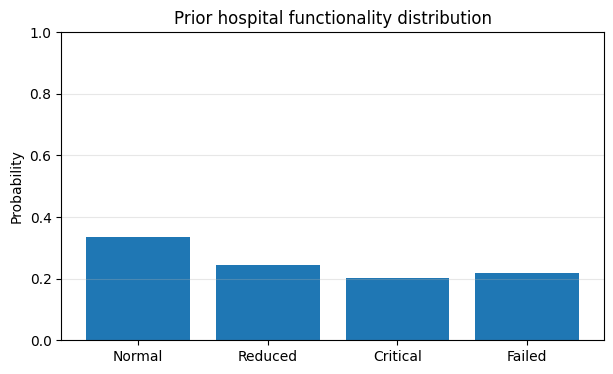

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(prior_hospital_summary["hospital_state"], prior_hospital_summary["probability"])
plt.ylabel("Probability")
plt.title("Prior hospital functionality distribution")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. Posterior updating with observations

Suppose we receive two observations after the hurricane:

1. `TOWER_B_failed = 1`
2. `Hospital = Critical`

The BN can answer inverse questions such as:

- Given the hospital is critical, how likely is substation failure?
- Given one communication tower is down, how likely is communication failure?
- Which infrastructure nodes are most likely responsible for the observed hospital state?

This is the main benefit of posterior updating.

In [15]:
# Evidence set 1: direct infrastructure observation.
evidence_tower_b_down = {
    "TOWER_B_failed": 1
}

posterior_after_tower_b = summarize_hospital(evidence=evidence_tower_b_down, priors=root_priors)

display(posterior_after_tower_b)

,hospital_state,probability
0,Normal,0.316784
1,Reduced,0.251069
2,Critical,0.208225
3,Failed,0.223922


In [16]:
# Evidence set 2: hospital functionality observation.
evidence_hospital_critical = {
    "Hospital": "Critical"
}

posterior_failures_given_hospital_critical = summarize_binary_posteriors(
    evidence=evidence_hospital_critical,
    priors=root_priors
)

display(posterior_failures_given_hospital_critical.sort_values(
    "p_failed_given_evidence",
    ascending=False
))

,variable,p_failed_given_evidence
1,SUB_1_physical_failed,0.895940
2,SUB_1_failed,0.861787
7,TOWER_C_failed,0.772703
4,WaterSupply_failed,0.623450
8,Communication_failed,0.549566
3,WTP_1_physical_failed,0.494862
6,TOWER_B_failed,0.393095
0,PP_1_failed,0.004183
5,TOWER_A_failed,0.001093


In [17]:
# Evidence set 3: combine infrastructure observation and hospital status.
evidence_combined = {
    "TOWER_B_failed": 1,
    "Hospital": "Critical"
}

posterior_combined_failures = summarize_binary_posteriors(
    evidence=evidence_combined,
    priors=root_priors
)

posterior_combined_hospital = summarize_hospital(
    evidence={"TOWER_B_failed": 1},
    priors=root_priors
)

display(posterior_combined_failures.sort_values(
    "p_failed_given_evidence",
    ascending=False
))
display(posterior_combined_hospital)

,variable,p_failed_given_evidence
6,TOWER_B_failed,1.000000
1,SUB_1_physical_failed,0.886830
2,SUB_1_failed,0.848924
7,TOWER_C_failed,0.769783
8,Communication_failed,0.674617
4,WaterSupply_failed,0.613817
3,WTP_1_physical_failed,0.489049
0,PP_1_failed,0.004140
5,TOWER_A_failed,0.001076


,hospital_state,probability
0,Normal,0.316784
1,Reduced,0.251069
2,Critical,0.208225
3,Failed,0.223922


In [18]:
# Compare prior vs posterior for selected infrastructure variables.
comparison = prior_binary_summary.rename(
    columns={"p_failed_given_evidence": "prior_p_failed"}
).merge(
    posterior_failures_given_hospital_critical.rename(
        columns={"p_failed_given_evidence": "posterior_p_failed_given_hospital_critical"}
    ),
    on="variable"
)

comparison["posterior_minus_prior"] = (
    comparison["posterior_p_failed_given_hospital_critical"] -
    comparison["prior_p_failed"]
)

comparison.sort_values("posterior_minus_prior", ascending=False)

,variable,prior_p_failed,posterior_p_failed_given_hospital_critical,posterior_minus_prior
2,SUB_1_failed,0.726157,0.861787,0.135630
4,WaterSupply_failed,0.508576,0.623450,0.114875
1,SUB_1_physical_failed,0.799877,0.895940,0.096064
8,Communication_failed,0.463586,0.549566,0.085981
3,WTP_1_physical_failed,0.423339,0.494862,0.071523
6,TOWER_B_failed,0.378927,0.393095,0.014168
7,TOWER_C_failed,0.762185,0.772703,0.010518
0,PP_1_failed,0.003731,0.004183,0.000452
5,TOWER_A_failed,0.001032,0.001093,0.000062


## 7. Raw data structure for a DBN

A Dynamic Bayesian Network extends the same logic across time.

For each time slice \(t\), you need at least four input tables.

### 7.1 Time-varying hazard input

Each row represents flood depth at one asset and one time step.

```text
time_step | timestamp | node_id | flood_depth_m | source
```

### 7.2 Time-varying infrastructure observations

Each row represents a report or observation about an asset or service.

```text
time_step | timestamp | node_or_service | observed_failed | confidence | source | notes
```

### 7.3 Time-varying hospital observations

Each row represents the hospital functionality state if observed.

```text
time_step | timestamp | hospital_id | observed_state | confidence | source | notes
```

### 7.4 Expert/log-informed transition parameters

Each row represents a transition assumption.

```text
node_type | p_recover_per_step | source | rationale
```

A simple temporal model for physical failure is:

$$
P(F_t=1 \mid F_{t-1}=0, d_t) = P_\text{fragility}(d_t)
$$

$$
P(F_t=1 \mid F_{t-1}=1, d_t) =
1 - p_\text{recover}(1 - P_\text{fragility}(d_t))
$$

Interpretation:

- if the asset was not failed previously, new failure is driven by current flood depth;
- if the asset was failed previously, it may recover, but recovery is less likely while flood damage remains high.

In [19]:
# Time-varying flood depth input for a DBN.
# These values are toy values showing flood rising and then receding.

dbn_flood_depth = pd.DataFrame([
    # time 0
    {"time_step": 0, "timestamp": "2026-09-01 00:00", "node_id": "PP_1", "flood_depth_m": 0.60, "source": "hydrodynamic_model"},
    {"time_step": 0, "timestamp": "2026-09-01 00:00", "node_id": "SUB_1", "flood_depth_m": 1.40, "source": "hydrodynamic_model"},
    {"time_step": 0, "timestamp": "2026-09-01 00:00", "node_id": "WTP_1", "flood_depth_m": 1.10, "source": "hydrodynamic_model"},
    {"time_step": 0, "timestamp": "2026-09-01 00:00", "node_id": "TOWER_A", "flood_depth_m": 0.30, "source": "hydrodynamic_model"},
    {"time_step": 0, "timestamp": "2026-09-01 00:00", "node_id": "TOWER_B", "flood_depth_m": 1.20, "source": "hydrodynamic_model"},
    {"time_step": 0, "timestamp": "2026-09-01 00:00", "node_id": "TOWER_C", "flood_depth_m": 2.00, "source": "hydrodynamic_model"},

    # time 1: flood worsens
    {"time_step": 1, "timestamp": "2026-09-01 06:00", "node_id": "PP_1", "flood_depth_m": 0.90, "source": "hydrodynamic_model"},
    {"time_step": 1, "timestamp": "2026-09-01 06:00", "node_id": "SUB_1", "flood_depth_m": 1.80, "source": "hydrodynamic_model"},
    {"time_step": 1, "timestamp": "2026-09-01 06:00", "node_id": "WTP_1", "flood_depth_m": 1.50, "source": "hydrodynamic_model"},
    {"time_step": 1, "timestamp": "2026-09-01 06:00", "node_id": "TOWER_A", "flood_depth_m": 0.50, "source": "hydrodynamic_model"},
    {"time_step": 1, "timestamp": "2026-09-01 06:00", "node_id": "TOWER_B", "flood_depth_m": 1.60, "source": "hydrodynamic_model"},
    {"time_step": 1, "timestamp": "2026-09-01 06:00", "node_id": "TOWER_C", "flood_depth_m": 2.20, "source": "hydrodynamic_model"},

    # time 2: flood begins to recede
    {"time_step": 2, "timestamp": "2026-09-01 12:00", "node_id": "PP_1", "flood_depth_m": 0.70, "source": "hydrodynamic_model"},
    {"time_step": 2, "timestamp": "2026-09-01 12:00", "node_id": "SUB_1", "flood_depth_m": 1.20, "source": "hydrodynamic_model"},
    {"time_step": 2, "timestamp": "2026-09-01 12:00", "node_id": "WTP_1", "flood_depth_m": 1.00, "source": "hydrodynamic_model"},
    {"time_step": 2, "timestamp": "2026-09-01 12:00", "node_id": "TOWER_A", "flood_depth_m": 0.20, "source": "hydrodynamic_model"},
    {"time_step": 2, "timestamp": "2026-09-01 12:00", "node_id": "TOWER_B", "flood_depth_m": 0.90, "source": "hydrodynamic_model"},
    {"time_step": 2, "timestamp": "2026-09-01 12:00", "node_id": "TOWER_C", "flood_depth_m": 1.50, "source": "hydrodynamic_model"},

    # time 3: flood mostly recedes
    {"time_step": 3, "timestamp": "2026-09-01 18:00", "node_id": "PP_1", "flood_depth_m": 0.20, "source": "hydrodynamic_model"},
    {"time_step": 3, "timestamp": "2026-09-01 18:00", "node_id": "SUB_1", "flood_depth_m": 0.50, "source": "hydrodynamic_model"},
    {"time_step": 3, "timestamp": "2026-09-01 18:00", "node_id": "WTP_1", "flood_depth_m": 0.30, "source": "hydrodynamic_model"},
    {"time_step": 3, "timestamp": "2026-09-01 18:00", "node_id": "TOWER_A", "flood_depth_m": 0.00, "source": "hydrodynamic_model"},
    {"time_step": 3, "timestamp": "2026-09-01 18:00", "node_id": "TOWER_B", "flood_depth_m": 0.30, "source": "hydrodynamic_model"},
    {"time_step": 3, "timestamp": "2026-09-01 18:00", "node_id": "TOWER_C", "flood_depth_m": 0.80, "source": "hydrodynamic_model"},
])

dbn_flood_depth.head(12)

,time_step,timestamp,node_id,flood_depth_m,source
0,0,2026-09-01 00:00,PP_1,0.6,hydrodynamic_model
1,0,2026-09-01 00:00,SUB_1,1.4,hydrodynamic_model
2,0,2026-09-01 00:00,WTP_1,1.1,hydrodynamic_model
3,0,2026-09-01 00:00,TOWER_A,0.3,hydrodynamic_model
4,0,2026-09-01 00:00,TOWER_B,1.2,hydrodynamic_model
5,0,2026-09-01 00:00,TOWER_C,2.0,hydrodynamic_model
6,1,2026-09-01 06:00,PP_1,0.9,hydrodynamic_model
7,1,2026-09-01 06:00,SUB_1,1.8,hydrodynamic_model
8,1,2026-09-01 06:00,WTP_1,1.5,hydrodynamic_model
9,1,2026-09-01 06:00,TOWER_A,0.5,hydrodynamic_model


In [20]:
# Time-varying observations for DBN posterior updating.
# Observations can be sparse and incomplete.

dbn_observations = pd.DataFrame([
    {"time_step": 0, "timestamp": "2026-09-01 00:30", "variable": "TOWER_B_failed", "observed_value": 1, "source": "EOC situation report", "confidence": 0.90},
    {"time_step": 1, "timestamp": "2026-09-01 06:30", "variable": "Hospital", "observed_value": "Critical", "source": "hospital emergency manager", "confidence": 0.85},
    {"time_step": 2, "timestamp": "2026-09-01 12:30", "variable": "WaterSupply_failed", "observed_value": 1, "source": "hospital facility log", "confidence": 0.80},
    {"time_step": 3, "timestamp": "2026-09-01 18:30", "variable": "Hospital", "observed_value": "Reduced", "source": "hospital emergency manager", "confidence": 0.80},
])

dbn_observations

,time_step,timestamp,variable,observed_value,source,confidence
0,0,2026-09-01 00:30,TOWER_B_failed,1,EOC situation report,0.90
1,1,2026-09-01 06:30,Hospital,Critical,hospital emergency manager,0.85
2,2,2026-09-01 12:30,WaterSupply_failed,1,hospital facility log,0.80
3,3,2026-09-01 18:30,Hospital,Reduced,hospital emergency manager,0.80


In [21]:
# Transition/recovery parameters.
# Real-world replacement:
# - Estimate from outage logs if enough data exist.
# - Otherwise elicit from experts: "Given this asset failed, what is the chance it recovers within one time step
#   if flood depth recedes and crews can access the site?"

transition_parameters = pd.DataFrame([
    {"node_type": "PowerPlant", "p_recover_per_step": 0.10, "source": "expert_elicitation", "rationale": "Power plant recovery may be slow after flood damage"},
    {"node_type": "Substation", "p_recover_per_step": 0.15, "source": "expert_elicitation", "rationale": "Substation inspection and repair may take time"},
    {"node_type": "WaterTreatmentPlant", "p_recover_per_step": 0.12, "source": "expert_elicitation", "rationale": "Water treatment recovery depends on equipment and water quality"},
    {"node_type": "CommunicationTower", "p_recover_per_step": 0.25, "source": "expert_elicitation", "rationale": "Communication sites may recover faster if backup power or mobile units are deployed"},
])

transition_parameters

,node_type,p_recover_per_step,source,rationale
0,PowerPlant,0.10,expert_elicitation,Power plant recovery may be slow after flood d...
1,Substation,0.15,expert_elicitation,Substation inspection and repair may take time
2,WaterTreatmentPlant,0.12,expert_elicitation,Water treatment recovery depends on equipment ...
3,CommunicationTower,0.25,expert_elicitation,Communication sites may recover faster if back...


## 8. DBN-style filtering example

The following function updates **root physical failure priors** over time.

This is a simplified time-sliced filter:

1. compute new damage probability from flood depth using fragility;
2. combine it with previous failure probability and recovery probability;
3. use the resulting priors in the static BN for that time slice;
4. optionally condition on observations at that time step.

For a publishable DBN implementation, you would typically keep the full joint distribution over time or use a DBN solver. This simplified version is still useful for explaining the input structure and workflow.

In [22]:
# Map root variables to asset nodes and asset types.
root_variable_metadata = pd.DataFrame([
    {"root_variable": "PP_1_failed", "node_id": "PP_1", "node_type": "PowerPlant"},
    {"root_variable": "SUB_1_physical_failed", "node_id": "SUB_1", "node_type": "Substation"},
    {"root_variable": "WTP_1_physical_failed", "node_id": "WTP_1", "node_type": "WaterTreatmentPlant"},
    {"root_variable": "TOWER_A_failed", "node_id": "TOWER_A", "node_type": "CommunicationTower"},
    {"root_variable": "TOWER_B_failed", "node_id": "TOWER_B", "node_type": "CommunicationTower"},
    {"root_variable": "TOWER_C_failed", "node_id": "TOWER_C", "node_type": "CommunicationTower"},
])

root_variable_metadata

,root_variable,node_id,node_type
0,PP_1_failed,PP_1,PowerPlant
1,SUB_1_physical_failed,SUB_1,Substation
2,WTP_1_physical_failed,WTP_1,WaterTreatmentPlant
3,TOWER_A_failed,TOWER_A,CommunicationTower
4,TOWER_B_failed,TOWER_B,CommunicationTower
5,TOWER_C_failed,TOWER_C,CommunicationTower


In [23]:
def compute_fragility_priors_for_time(t):
    """Compute fragility-only failure priors for root variables at time step t."""
    df = (
        dbn_flood_depth[dbn_flood_depth["time_step"] == t]
        .merge(asset_inventory[["node_id", "node_type"]], on="node_id", how="left")
        .merge(fragility_parameters, on="node_type", how="left")
    )

    priors = {}
    for _, meta in root_variable_metadata.iterrows():
        row = df[df["node_id"] == meta["node_id"]].iloc[0]
        priors[meta["root_variable"]] = lognormal_fragility(
            row["flood_depth_m"],
            row["median_depth_m"],
            row["beta"]
        )

    return priors


def temporal_update_root_prior(previous_p_failed, fragility_p_failed, p_recover):
    """
    Simple temporal transition for physical failure.

    P(F_t=1 | F_{t-1}=0, d_t) = fragility_p_failed

    P(F_t=1 | F_{t-1}=1, d_t) =
        1 - p_recover * (1 - fragility_p_failed)

    Marginalized over previous_p_failed:
        P(F_t=1) =
        P(F_{t-1}=1) * P(F_t=1 | F_{t-1}=1, d_t)
        + P(F_{t-1}=0) * P(F_t=1 | F_{t-1}=0, d_t)
    """
    p_fail_if_prev_ok = fragility_p_failed
    p_fail_if_prev_failed = 1.0 - p_recover * (1.0 - fragility_p_failed)

    return (
        previous_p_failed * p_fail_if_prev_failed
        + (1.0 - previous_p_failed) * p_fail_if_prev_ok
    )


def get_time_step_evidence(t):
    """
    Extract hard evidence for a time step.

    This toy example treats observations as certain.
    In a more advanced version, confidence values can be used as soft evidence.
    """
    evidence = {}
    for _, row in dbn_observations[dbn_observations["time_step"] == t].iterrows():
        evidence[row["variable"]] = row["observed_value"]
    return evidence


def dbn_filter():
    """
    Run a simple DBN-style sequential filter.

    At each time step:
    - update root priors using flood fragility + previous root failure probability;
    - apply static BN inference;
    - condition on available observations;
    - store hospital posterior and selected infrastructure posteriors.

    Note:
    This simplified filter propagates marginal root posteriors rather than the full joint distribution.
    It is transparent and useful for method demonstration, but a formal DBN should preserve the joint state.
    """
    time_steps = sorted(dbn_flood_depth["time_step"].unique())

    previous_root_posterior = None
    results = []
    root_prior_records = []

    for t in time_steps:
        fragility_priors = compute_fragility_priors_for_time(t)

        if previous_root_posterior is None:
            dynamic_root_priors = fragility_priors.copy()
        else:
            dynamic_root_priors = {}
            for _, meta in root_variable_metadata.iterrows():
                var = meta["root_variable"]
                node_type = meta["node_type"]
                p_recover = transition_parameters.loc[
                    transition_parameters["node_type"] == node_type,
                    "p_recover_per_step"
                ].iloc[0]

                dynamic_root_priors[var] = temporal_update_root_prior(
                    previous_p_failed=previous_root_posterior[var],
                    fragility_p_failed=fragility_priors[var],
                    p_recover=p_recover
                )

        # Store dynamic root priors.
        for var, p in dynamic_root_priors.items():
            root_prior_records.append({
                "time_step": t,
                "root_variable": var,
                "dynamic_prior_p_failed": p,
                "fragility_only_p_failed": fragility_priors[var],
            })

        evidence = get_time_step_evidence(t)

        # Hospital posterior at time t.
        hosp_dist = query_distribution("Hospital", evidence=evidence, priors=dynamic_root_priors)

        # Binary posteriors at time t.
        binary_summary = summarize_binary_posteriors(evidence=evidence, priors=dynamic_root_priors)

        # Store results.
        record = {
            "time_step": t,
            "evidence": evidence,
        }
        for state in hospital_states:
            record[f"P_Hospital_{state}"] = hosp_dist[state]

        for var in ["SUB_1_failed", "WaterSupply_failed", "Communication_failed"]:
            record[f"P_{var}"] = float(binary_summary.loc[
                binary_summary["variable"] == var,
                "p_failed_given_evidence"
            ].iloc[0])

        results.append(record)

        # For the next time step, use posterior marginals for root variables.
        previous_root_posterior = {}
        for var in root_priors:
            dist = query_distribution(var, evidence=evidence, priors=dynamic_root_priors)
            previous_root_posterior[var] = dist[1]

    return pd.DataFrame(results), pd.DataFrame(root_prior_records)


dbn_results, dbn_root_priors = dbn_filter()

display(dbn_results)
display(dbn_root_priors.head(12))

,time_step,evidence,P_Hospital_Normal,P_Hospital_Reduced,P_Hospital_Critical,P_Hospital_Failed,P_SUB_1_failed,P_WaterSupply_failed,P_Communication_failed
0,0,{'TOWER_B_failed': 1},0.316784,0.251069,0.208225,0.223922,0.726157,0.508576,0.598018
1,1,{'Hospital': 'Critical'},0.000000,0.000000,1.000000,0.000000,0.926374,0.837769,0.668800
2,2,{'WaterSupply_failed': 1},0.164281,0.271935,0.256579,0.307206,0.869300,1.000000,0.581244
3,3,{'Hospital': 'Reduced'},0.000000,1.000000,0.000000,0.000000,0.774776,0.833894,0.517028


,time_step,root_variable,dynamic_prior_p_failed,fragility_only_p_failed
0,0,PP_1_failed,0.003731,0.003731
1,0,SUB_1_physical_failed,0.799877,0.799877
2,0,WTP_1_physical_failed,0.423339,0.423339
3,0,TOWER_A_failed,0.001032,0.001032
4,0,TOWER_B_failed,0.378927,0.378927
5,0,TOWER_C_failed,0.762185,0.762185
6,1,PP_1_failed,0.041224,0.037993
7,1,SUB_1_physical_failed,0.977320,0.929147
8,1,WTP_1_physical_failed,0.805492,0.690009
9,1,TOWER_A_failed,0.020494,0.019736


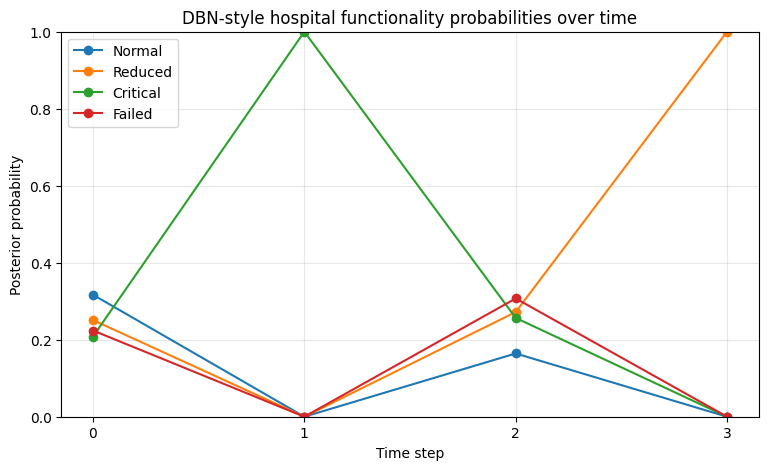

In [24]:
# Plot hospital state probabilities over time.
plt.figure(figsize=(9, 5))
for state in hospital_states:
    plt.plot(
        dbn_results["time_step"],
        dbn_results[f"P_Hospital_{state}"],
        marker="o",
        label=state
    )

plt.xlabel("Time step")
plt.ylabel("Posterior probability")
plt.title("DBN-style hospital functionality probabilities over time")
plt.xticks(dbn_results["time_step"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

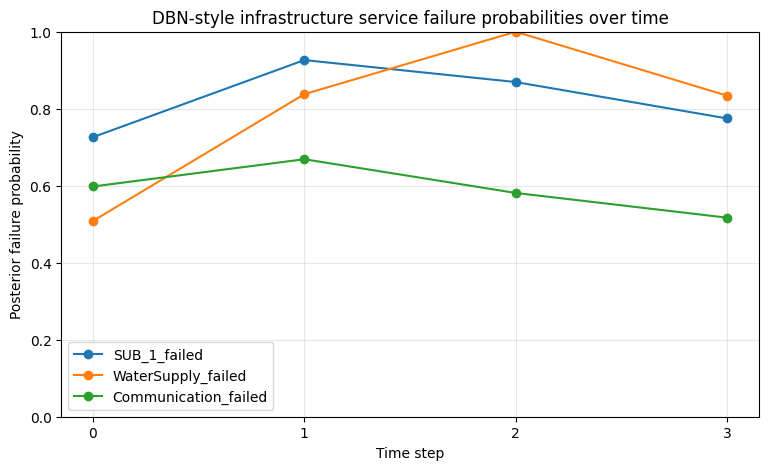

In [25]:
# Plot selected infrastructure service failure probabilities over time.
service_cols = ["P_SUB_1_failed", "P_WaterSupply_failed", "P_Communication_failed"]

plt.figure(figsize=(9, 5))
for col in service_cols:
    plt.plot(
        dbn_results["time_step"],
        dbn_results[col],
        marker="o",
        label=col.replace("P_", "")
    )

plt.xlabel("Time step")
plt.ylabel("Posterior failure probability")
plt.title("DBN-style infrastructure service failure probabilities over time")
plt.xticks(dbn_results["time_step"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. How to replace the toy data with real study data

### 9.1 Replace asset inventory

Use GIS layers or infrastructure datasets to build:

```text
node_id | node_type | name | operator | lat | lon | elevation_m
```

For example:

- hospitals: state health facility data, HIFLD, local emergency management data;
- substations/power plants: utility records, HIFLD, OpenStreetMap if appropriate;
- water treatment plants: state environmental agency, local utility;
- communication towers: FCC/ASR, HIFLD, county communication assets.

### 9.2 Replace flood-depth input

Intersect asset locations with hurricane flood-depth rasters or model outputs:

```text
scenario_id | time_step | timestamp | node_id | flood_depth_m | source
```

For a static BN, one time step may be enough.  
For a DBN, use multiple time steps.

### 9.3 Replace fragility parameters

For each asset type, use literature-based or expert-informed parameters:

```text
node_type | median_depth_m | beta | failure_mode | source
```

If only verbal expert knowledge is available, map verbal anchors to numerical ranges:

| Verbal anchor | Possible range |
|---|---:|
| Very low | 0.01–0.10 |
| Low | 0.10–0.25 |
| Medium | 0.25–0.50 |
| High | 0.50–0.75 |
| Very high | 0.75–0.95 |

Then aggregate across experts.

### 9.4 Replace Noisy-OR causal strengths

For each dependency, ask experts:

> If this parent infrastructure component fails, and all other causes are absent, what is the probability that the child service fails or degrades?

Store responses as:

```text
expert_id | parent | child | verbal_probability | numeric_probability | rationale
```

Then aggregate into a causal-strength table.

### 9.5 Replace observations

Use post-event logs:

```text
time_step | timestamp | variable | observed_value | source | confidence
```

Examples:

- `TOWER_B_failed = 1`
- `WaterSupply_failed = 1`
- `Hospital = Critical`

These observations become evidence for posterior updating.

## 10. What this toy example demonstrates

This notebook demonstrates the following modeling logic:

```text
Flood depth
    ↓
Fragility curve
    ↓
Physical failure probability of each infrastructure node
    ↓
Noisy-OR infrastructure service model
    ↓
Noisy-OR / cumulative Noisy-OR hospital functionality model
    ↓
Prior hospital functionality probabilities
    ↓
Posterior updating when infrastructure or hospital observations arrive
    ↓
DBN-style time-sliced updating for hurricane evolution and recovery
```

### Key modeling interpretation

- Fragility curves provide **hazard-informed priors**.
- Expert elicitation provides **causal strengths** and **leak probabilities**.
- Noisy-OR reduces the burden of specifying large CPTs.
- Observations update posterior probabilities through Bayesian conditioning.
- DBN inputs require time-indexed flood depths, observations, and transition/recovery assumptions.

### Important limitation

This is a toy model. For a formal study, you should:

1. validate or justify fragility parameters;
2. document expert elicitation procedures;
3. test sensitivity to causal strengths and leak probabilities;
4. consider soft evidence rather than treating all observations as certain;
5. use a formal DBN inference engine if the network becomes large or if joint temporal dependencies matter.